In [6]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Figure explaining calibration process

In [320]:
def plot_ssh(data, vmax=2, cmap=cmocean.cm.balance, add_colorbar=False, axes=True, show_rmse=False, figsize=(4,4), **kw):
    levels_field = np.arange(-vmax,vmax+0.5,0.5)
    
    plt.figure(figsize=figsize)

    levels = np.arange(-vmax,vmax+0.5,0.5)
    data.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=add_colorbar, **kw)
    plt.title('')

    if axes:
        plt.xticks(np.arange(0,25,5), [f"{i}"+"$^{\circ}\mathrm{E}$" for i in np.arange(0,25,5)])
        plt.yticks(np.arange(30,55,5), [f"{i}"+"$^{\circ}\mathrm{N}$" for i in np.arange(30,55,5)])
        plt.xlabel('')
        plt.ylabel('')
    else:
        plt.xticks([])
        plt.yticks([])
        plt.xlabel('')
        plt.ylabel('')
    
    if show_rmse:
        rmse = float(np.sqrt(((data - observation_netcdf.e_mean.isel(zi=0))**2).mean()))
        plt.text(1,31,f'RMSE$={rmse:.2f}$m', fontsize=20)

    plt.gca().set_aspect(1)

In [282]:
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling/metrics*')

In [283]:
observation_netcdf = xr.open_dataset('../scripts/R32/R2_FGR3_series_loss.nc')

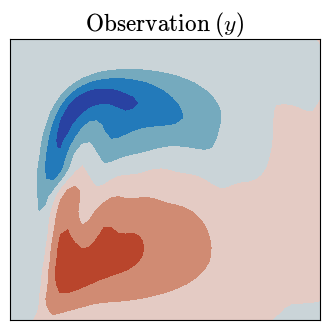

In [288]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0),axes=False, add_colorbar=False)
plt.title('Observation ($y$)')
plt.savefig('paper_figures/fDNS-no-colorbar.pdf')

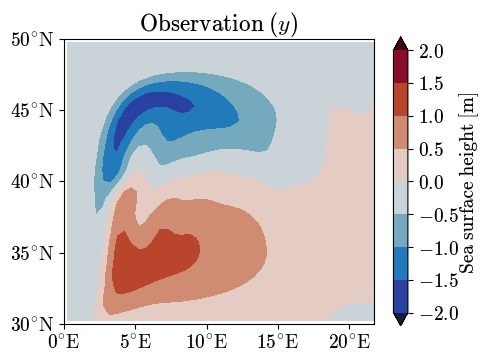

In [285]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0),axes=True, add_colorbar=True, figsize=(5,5),cbar_kwargs={'label': 'Sea surface height [m]', 'shrink':0.75})
plt.title('Observation ($y$)')
plt.savefig('paper_figures/fDNS.pdf')

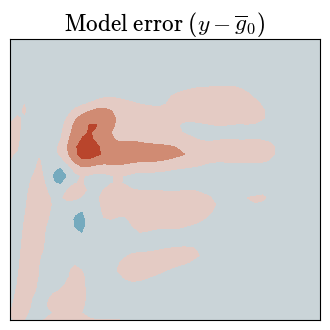

In [286]:
plot_ssh(observation_netcdf.e_mean.isel(zi=0) - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('Model error ($y - \overline{g}_0$)')
plt.savefig('paper_figures/model_error.pdf')

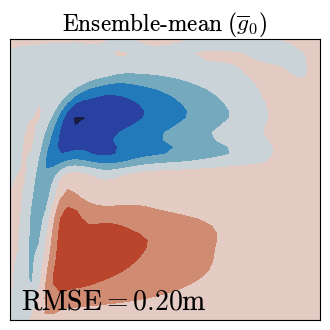

In [321]:
plot_ssh(metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False, show_rmse=True)
plt.title('Ensemble-mean ($\overline{g}_0$)')
plt.savefig('paper_figures/ensemble_mean.pdf')

In [260]:
model_error = observation_netcdf.e_mean.isel(zi=0) - metrics.isel(iter=0,zi=0).e_mean.mean('ens')
model_response = metrics.isel(iter=0,zi=0).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens')

In [261]:
(model_error * model_response).sum(['xh', 'yh']).values

array([  1.7863002 ,  28.922705  , -22.267393  ,  14.974466  ,
        17.397379  ,  -4.2011294 ,   6.633449  ,   9.103613  ,
        30.55229   ,  -0.36905253, -20.421946  ,  -8.1574545 ,
         0.        ,  18.056622  , -24.502853  ,   8.124358  ,
       -34.476604  ,  -7.9678516 ,   5.322609  , -17.313917  ,
       -21.797806  ,  21.925697  ,   0.        , -27.763968  ,
       -45.999577  ,   0.        ,  -3.5704486 ,  31.807316  ,
         0.        ,  -9.5846    ,   0.        ,  30.808937  ,
       -19.157406  , -33.978188  ,   0.        ,  45.61058   ,
       -20.433252  ,  26.783945  , -34.0828    ,  11.014891  ,
        16.861666  ,   0.        ,   0.        , -45.68458   ,
       -38.339954  ,  -7.161306  ,  -9.786346  ,   0.        ,
        17.495668  ,  21.483652  ,   4.4626684 ,  17.01449   ,
        -5.060383  ,   0.        ,   0.        ,  -3.4482841 ,
        40.08217   ,   0.        , -48.258392  ,  47.167915  ,
       -26.134384  ,  29.155212  ,  -4.892329  ,  31.15

In [292]:
xr.corr(model_error, model_response, ['xh', 'yh'])[-3].values


array(-0.581729, dtype=float32)

In [293]:
xr.corr(model_error, model_response, ['xh', 'yh'])[-41].values


array(0.44272238, dtype=float32)

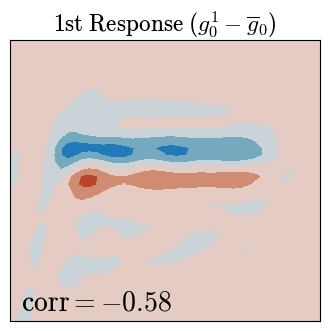

In [322]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-3).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('1st Response ($g_0^1 - \overline{g}_0$)')
plt.text(1,31,'corr$=-0.58$', fontsize=20)
plt.savefig('paper_figures/model_response_1.pdf')

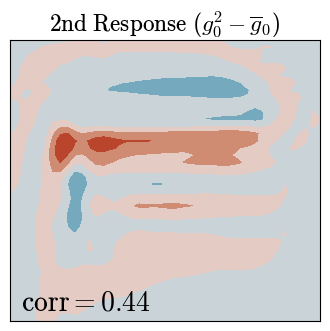

In [323]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-41).e_mean - metrics.isel(iter=0,zi=0).e_mean.mean('ens'),axes=False)
plt.title('2nd Response ($g_0^2 - \overline{g}_0$)')
plt.text(1,31,'corr$=0.44$', fontsize=20)
plt.savefig('paper_figures/model_response_2.pdf')

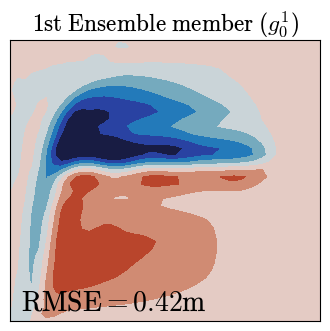

In [324]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-3).e_mean,axes=False, show_rmse=True)
plt.title('1st Ensemble member ($g_0^1$)')
plt.savefig('paper_figures/model_1.pdf')

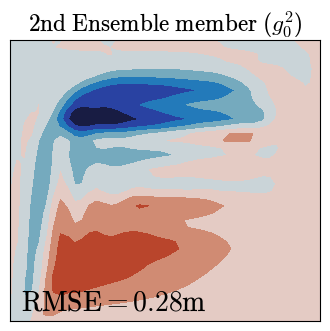

In [325]:
plot_ssh(metrics.isel(iter=0,zi=0,ens=-41).e_mean,axes=False, show_rmse=True)
plt.title('2nd Ensemble member ($g_0^2$)')
plt.savefig('paper_figures/model_2.pdf')

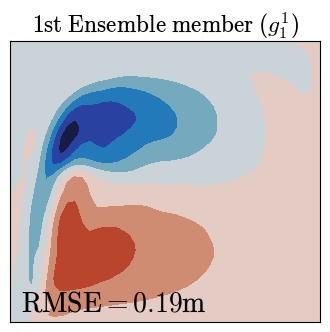

In [326]:
plot_ssh(metrics.isel(iter=1,zi=0,ens=-3).e_mean,axes=False, show_rmse=True)
plt.title('1st Ensemble member ($g_1^1$)')
plt.savefig('paper_figures/iter_1_model_1.pdf')

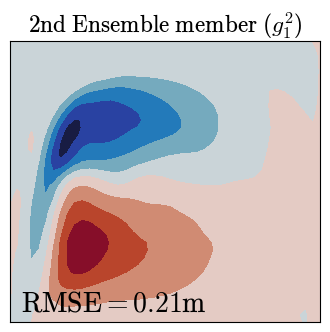

In [327]:
plot_ssh(metrics.isel(iter=1,zi=0,ens=-41).e_mean,axes=False, show_rmse=True)
plt.title('2nd Ensemble member ($g_1^2$)')
plt.savefig('paper_figures/iter_1_model_2.pdf')

# Resolving eddy energy

In [7]:
from helpers.collection_of_experiments import CollectionOfExperiments
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')
ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration', additional_subfolder='output')
ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization', additional_subfolder='output')

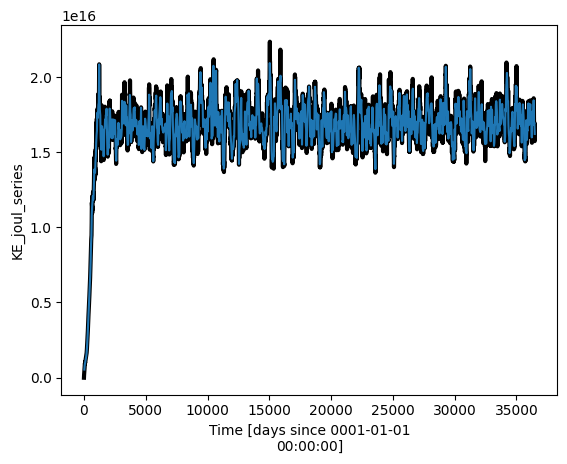

In [9]:
ds['R32'].series.KE.sum('Layer').plot(lw=3, color='k')
ds['R32'].KE_joul_series.sum('zl').plot()

In [11]:
ds['R32'].EKE_joul.sum().values

array(1.08218888e+16)

In [15]:
ds['R32_R2_FGR3'].EKE_joul.sum().values / ds['R32'].EKE_joul.sum().values * 100

23.863317394818935

In [17]:
ds['R2'].EKE_joul.sum().values / ds['R32'].EKE_joul.sum().values * 100


0.34102843507692165

# Resolving eddy energy in spectrum

(20, 22) (20, 22)


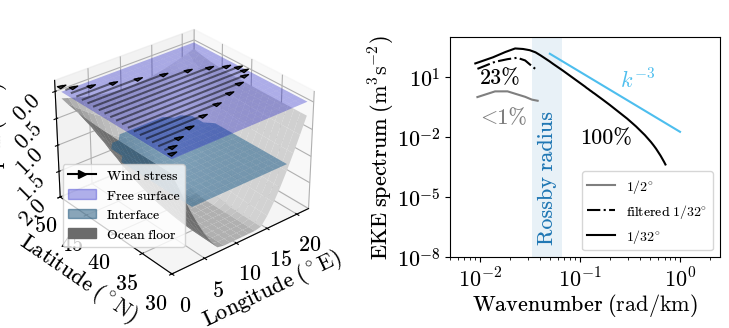

In [4]:
import cmocean
default_rcParams({'font.size': 16,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.5, 'figure.subplot.hspace': 0.4})
fig = plt.figure(figsize=(9,4))
lightblue = [0.3010, 0.7450, 0.9330]
exps =['R2', 'R32_R2_FGR3', 'R32']
labels=['$1/2^{\circ}$', 'filtered $1/32^{\circ}$', '$1/32^{\circ}$']
colors = ['tab:gray', 'k', 'k']
lss = ['-', '-.', '-']
def plot_spectrum(zl=0):
    for exp,label,color,ls in zip(exps,labels,colors,lss):
        ds[exp].EKE_spectrum.isel(zl=zl).plot(label=label,color=color,ls=ls)
    plt.xlabel(r'Wavenumber ($\mathrm{rad}/\mathrm{km}$)')
    plt.ylabel('EKE spectrum ($\mathrm{m}^3\mathrm{s}^{-2}$)')
    k = [5e-5, 1e-3]
    E = [1.5e+2, 0]
    plt.text(2.5e-4,0.3e+1,'$k^{-3}$',color=lightblue)
    E[1] = E[0] * (k[1]/k[0])**(-3)
    plt.loglog(k,E,ls='-', color=lightblue)
    plt.title('')
    plt.ylim([1e-8,1e+3])
    plt.xticks([1e-5,1e-4,1e-3],['$10^{-2}$', '$10^{-1}$', '$10^{0}$'])
    plt.xlim([5e-6, 2.5e-3])
    plt.text(1e-5, 5e-2, '<1%', color='tab:gray')
    plt.text(1e-5, 5e0, '23%', color='k')
    plt.text(1e-4, 5e-3, '100%', color='k')
    
def plot_vorticity(exp):
    field = ds[exp].RV_f.isel(zl=0,Time=-1)
    if exp=='R64':
        field = field.coarsen(xq=2,yq=2,boundary='trim').mean().compute()
    im = field.plot.imshow(vmin=-0.2, vmax=0.2, cmap=cmocean.cm.balance, add_colorbar=False, interpolation='none')#, rasterized=True) #interpolation='none',
    plt.xticks([0,5,10,15,20])
    plt.yticks([30,35,40,45,50])
    plt.xlim([0,22])
    plt.ylim([30,50])
    plt.xlabel('Longitude ($^\circ\mathrm{E}$)')
    plt.ylabel('Latitude ($^\circ\mathrm{N}$)')
    plt.title('')
    plt.gca().set_aspect(1)
    return im

ax = fig.add_axes([0.1, 0.12, 0.4, 0.7], projection='3d')
ds.plot_domain(ax)
plt.xlabel('Longitude ($^\circ\mathrm{E}$)')
plt.ylabel('Latitude ($^\circ\mathrm{N}$)')

ax = fig.add_axes([0.6, 0.2, 0.3, 0.55]); plt.sca(ax)
plot_spectrum(zl=0)
# Baroclinic deformation radius
Rd1 = 30000
Rd2 = 15000
plt.axvspan(1/Rd1, 1/Rd2, color='tab:blue', alpha=0.1, lw=0)
plt.text(3.8e-5,1e-4,'Rossby radius', fontsize=16, color='tab:blue', rotation='vertical', verticalalignment='center')
#plt.title('Upper Layer', loc='right')
plt.title('')
#plt.legend(ncol=5, bbox_to_anchor=(2.6,-0.25), title='Biharmonic Smagorinsky models with $C_S=0.06$')
plt.legend(ncol=1, fontsize=10, loc='lower right')

# fig.text(0.15,0.08,'(a)', fontsize=20);
# fig.text(0.45,0.08,'(b)', fontsize=20);
# fig.text(0.70,0.08,'(c)', fontsize=20);

plt.savefig('paper_figures/DoubleGyre.pdf', pad_inches=0.3, dpi=200)

In [53]:
EKE_filtered = float(np.diff(ds['R32_R2_FGR3'].EKE_spectrum.freq_r)[0] * ds['R32_R2_FGR3'].EKE_spectrum.isel(zl=0).sum())

In [54]:
EKE_dns = float(np.diff(ds['R32'].EKE_spectrum.freq_r)[0] * ds['R32'].EKE_spectrum.isel(zl=0).sum())

In [55]:
EKE_coarse = float(np.diff(ds['R2'].EKE_spectrum.freq_r)[0] * ds['R2'].EKE_spectrum.isel(zl=0).sum())

In [60]:
# Estimates are similar
EKE_filtered / EKE_dns * 100

22.735816551336168

In [61]:
# Again similar
EKE_coarse / EKE_dns * 100

0.5201881429089125

# Convergence 

# 1. Compute metrics for baselines

In [8]:
sys.path.append('../calibration_driver/helpers')
from metrics_DG import return_climate_metrics

In [9]:
ds['R2'], ds['eANN-64-N8-forcing-fluxes-R2']

(<helpers.experiment.Experiment at 0x7f662342fa50>,
 <helpers.experiment.Experiment at 0x7f6623491010>)

In [10]:
metrics_eANN = return_climate_metrics('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization/eANN/64/N8-forcing-fluxes/R2/output', 7300, "e_mean", "e_std", "KE_mean", "KE_std", "APE_mean", "APE_std")

In [107]:
observation = xr.open_dataset('/home/pp2681/calibration/scripts/R32/R2_FGR3_series_loss.nc').astype('float64')
metrics_eANN = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_scaling/metrics*.nc')
metrics_unparameterized = return_climate_metrics('/scratch/pp2681/mom6/Feb2022/bare/R2/output', 7300, "e_mean", "e_std", "KE_mean", "KE_std", "APE_mean", "APE_std")
metrics= xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling/metrics*.nc')

def RMSE(x,y):
    return float(np.sqrt(np.mean((x-y)**2)))

default_rcParams({'font.size': 14,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.5, 'figure.subplot.hspace': 0.4})
def plot_metrics(color='tab:blue'):
    #metrics = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/metrics*.nc')

    j=0
    for layer in range(2):
        for metric, label, units in zip(
            [
                'KE_mean',
                'APE_mean',
                'e_mean_RMSE',
                'e_std_RMSE'
            ],
            [
                '$<\mathrm{KE}>_{\mathrm{mean}}$',
                '$<\mathrm{APE}>_{\mathrm{mean}}$',
                '$<e>_{\mathrm{mean}}$',
                '$<e>_{\mathrm{std}}$',
            ],
            [
                '[PJ]',
                '[PJ]',
                'RMSE [m]',
                'RMSE [m]'
            ]):
            j = j + 1
            data = metrics[metric]
            if 'zi' in data.dims:
                layer_coord = 'zi'
            elif 'zl' in data.dims:
                layer_coord = 'zl'

            data = data[{layer_coord: layer}]

            try:
                truth = observation[metric][{layer_coord: layer}]
            except:
                truth = np.nan
            
            plt.subplot(2,4,j)

            mean = metrics_eANN[metric][{layer_coord: layer}].mean('ens')
            std = metrics_eANN[metric][{layer_coord: layer}].std('ens')
            x = mean.iter
            plt.errorbar(x, mean, yerr=std, fmt='o', capsize=4, color='tab:red', label='$1/2^{\circ}$ eANN (1 param)', ls='-')

            mean = data.mean('ens')
            std = data.std('ens')
            x = mean.iter
            plt.errorbar(x, mean, yerr=std, fmt='o', capsize=4, color=color, label='$1/2^{\circ}$ eANN (14 params)', ls='-')

            plt.title(label)

            plt.axhline(y=truth, color='k', ls='-.', label='filtered $1/32^{\circ}$', zorder=100, lw=2)
            
            if metric in ['KE_mean', 'APE_mean']:
                y_unparameterized = metrics_unparameterized[metric][layer]
            elif metric == 'e_mean_RMSE':
                y_unparameterized = RMSE(metrics_unparameterized['e_mean'][layer], observation['e_mean'][{layer_coord: layer}])
            elif metric == 'e_std_RMSE':
                y_unparameterized = RMSE(metrics_unparameterized['e_std'][layer], observation['e_std'][{layer_coord: layer}])
            
            plt.axhline(y=y_unparameterized, color='tab:gray', ls='-', label='$1/2^{\circ}$', lw=2)

            # y_mean = metrics_eANN[metric][{layer_coord: layer}].mean('ens')
            # y_std = metrics_eANN[metric][{layer_coord: layer}].std('ens')

            # x = [-0.5,9.5]
            # plt.fill_between(
            #     x,
            #     [y_mean - y_std, y_mean - y_std],
            #     [y_mean + y_std, y_mean + y_std],
            #     color='tab:red',
            #     alpha=0.3
            # )

            # optional: draw the mean line on top
            #plt.plot(x, [y_mean, y_mean], color='tab:red', ls='-', label='$1/2^{\\circ}$ eANN offline \n ($\\alpha=1\\pm0.25$)')

            plt.ylabel(units)
            
            ax = plt.gca()

            # Upper row
            if j == 1:
                ax.text(
                    -0.35, 0.5, 'Upper layer',
                    transform=ax.transAxes,
                    fontsize=20,
                    fontweight='bold',
                    va='center',
                    ha='right',
                    rotation=90
                )

            # Lower row
            if j == 5:
                ax.text(
                    -0.35, 0.5, 'Lower layer',
                    transform=ax.transAxes,
                    fontsize=20,
                    fontweight='bold',
                    va='center',
                    ha='right',
                    rotation=90
                )

            plt.grid()
            plt.ylim([0,None])
            plt.xticks(np.arange(10))
            if j>4:
                plt.xlabel('Iteration')

    plt.tight_layout()
    plt.subplot(2,4,5)
    plt.ylim([-0.2,1])
    plt.subplot(2,4,2)
    plt.ylim([0,1.2])
    plt.subplot(2,4,3)
    plt.yticks(np.arange(0,0.35,0.05))
    plt.ylim([0,0.35])
    plt.subplot(2,4,4)
    plt.yticks(np.arange(0,0.16,0.02))
    plt.ylim([0,0.16])
    plt.subplot(2,4,7)
    plt.yticks(np.arange(0,35,5))
    plt.ylim([0,35])
    plt.subplot(2,4,8)
    plt.yticks(np.arange(0,16,2))
    plt.subplot(2,4,6)
    plt.ylim([0,110])
    plt.subplot(2,4,5)
    plt.legend(fontsize=14, ncol=4, bbox_to_anchor=(2.5,-0.4), loc='center')
    plt.gcf().align_ylabels(plt.gcf().axes)

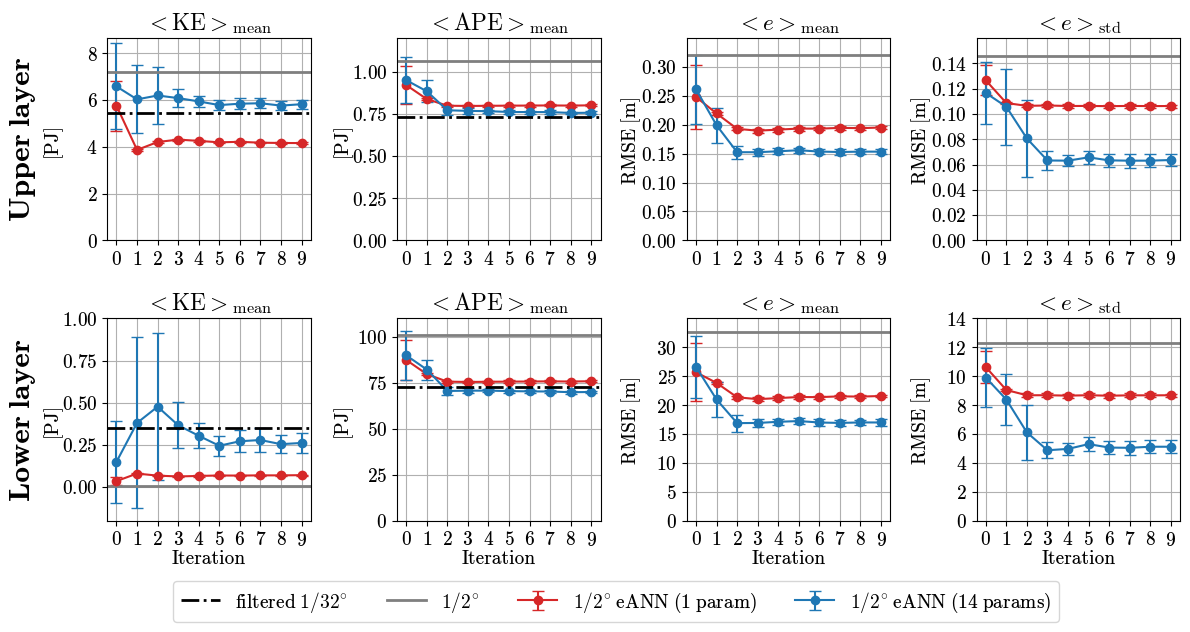

In [108]:
plt.figure(figsize=(12,6))
plot_metrics()
plt.savefig('paper_figures/metrics.pdf')

In [85]:
observation = xr.open_dataset('/home/pp2681/calibration/scripts/R32/R2_FGR3_series_loss.nc').astype('float64')
metrics_eANN = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_scaling/metrics*.nc')
metrics_unparameterized = return_climate_metrics('/scratch/pp2681/mom6/Feb2022/bare/R2/output', 7300, "e_mean", "e_std", "KE_mean", "KE_std", "APE_mean", "APE_std")
metrics= xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_mean_only_scaling/metrics*.nc')

def RMSE(x,y):
    return float(np.sqrt(np.mean((x-y)**2)))

default_rcParams({'font.size': 14,'axes.formatter.limits': (-2,4), 'figure.subplot.wspace': 0.5, 'figure.subplot.hspace': 0.4})
def plot_metrics(color='tab:blue'):
    #metrics = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/metrics*.nc')

    j=0
    for metric, label, units in zip(
            [
                'KE_mean',
                'APE_mean',
                'e_mean_RMSE',
                'e_std_RMSE'
            ],
            [
                '$<\mathrm{KE}>_{\mathrm{mean}}$',
                '$<\mathrm{APE}>_{\mathrm{mean}}$',
                '$<e>_{\mathrm{mean}}$',
                '$<e>_{\mathrm{std}}$',
            ],
            [
                '[PJ]',
                '[PJ]',
                'RMSE [m]',
                'RMSE [m]'
        ]):
        for layer in range(2):
            j = j + 1
            data = metrics[metric]
            if 'zi' in data.dims:
                layer_coord = 'zi'
            elif 'zl' in data.dims:
                layer_coord = 'zl'

            data = data[{layer_coord: layer}]

            try:
                truth = observation[metric][{layer_coord: layer}]
            except:
                truth = np.nan
            
            plt.subplot(4,2,j)

            mean = metrics_eANN[metric][{layer_coord: layer}].mean('ens')
            std = metrics_eANN[metric][{layer_coord: layer}].std('ens')
            x = mean.iter
            plt.errorbar(x, mean, yerr=std, fmt='o', capsize=4, color='tab:red', label='$1/2^{\circ}$ eANN (1 param)', ls='-')

            mean = data.mean('ens')
            std = data.std('ens')
            x = mean.iter
            plt.errorbar(x, mean, yerr=std, fmt='o', capsize=4, color=color, label='$1/2^{\circ}$ eANN (14 params)', ls='-')

            plt.axhline(y=truth, color='k', ls='-.', label='filtered $1/32^{\circ}$', zorder=100, lw=2)
            
            if metric in ['KE_mean', 'APE_mean']:
                y_unparameterized = metrics_unparameterized[metric][layer]
            elif metric == 'e_mean_RMSE':
                y_unparameterized = RMSE(metrics_unparameterized['e_mean'][layer], observation['e_mean'][{layer_coord: layer}])
            elif metric == 'e_std_RMSE':
                y_unparameterized = RMSE(metrics_unparameterized['e_std'][layer], observation['e_std'][{layer_coord: layer}])
            
            plt.axhline(y=y_unparameterized, color='tab:gray', ls='-', label='$1/2^{\circ}$', lw=2)
            
            plt.ylabel(label + '\n' + units, fontsize=20)
            
            ax = plt.gca()

            # Upper row
            if j == 1:
                ax.text(
                    0.7, 1.1, 'Upper layer',
                    transform=ax.transAxes,
                    fontsize=20,
                    fontweight='bold',
                    va='center',
                    ha='right',
                )

            # Lower row
            if j == 2:
                ax.text(
                    0.7, 1.1, 'Lower layer',
                    transform=ax.transAxes,
                    fontsize=20,
                    fontweight='bold',
                    va='center',
                    ha='right',
                )

            plt.grid()
            plt.ylim([0,None])
            plt.xticks(np.arange(10))
            if j>6:
                plt.xlabel('Iteration')

    plt.tight_layout()
    plt.subplot(4,2,2)
    plt.ylim([-0.2,1.0])
    plt.subplot(4,2,3)
    plt.ylim([0, 1.1])
    plt.subplot(4,2,4)
    plt.ylim([0, 110])
    plt.subplot(4,2,5)
    plt.yticks(np.arange(0,0.35,0.05))
    plt.ylim([0,0.35])
    plt.subplot(4,2,6)
    plt.yticks(np.arange(0,35,5))
    plt.ylim([0,35])
    plt.subplot(4,2,7)
    plt.yticks(np.arange(0,0.16,0.02))
    plt.ylim([0,0.16])
    plt.subplot(4,2,8)
    plt.yticks(np.arange(0,16,2))

    # plt.subplot(2,4,5)
    # plt.ylim([-0.2,1])
    # plt.subplot(2,4,2)
    # plt.ylim([0,1.2])
    # plt.subplot(2,4,3)
    # plt.yticks(np.arange(0,0.35,0.05))
    # plt.ylim([0,0.35])
    # plt.subplot(2,4,4)
    # plt.yticks(np.arange(0,0.16,0.02))
    # plt.ylim([0,0.16])
    # plt.subplot(2,4,7)
    # plt.yticks(np.arange(0,35,5))
    # plt.ylim([0,35])
    # plt.subplot(2,4,8)
    # plt.yticks(np.arange(0,16,2))
    # plt.subplot(2,4,6)
    # plt.ylim([0,110])
    # plt.subplot(2,4,8)
    plt.subplot(4,2,3)
    plt.legend(fontsize=12, framealpha=1.0)
    plt.gcf().align_ylabels(plt.gcf().axes)

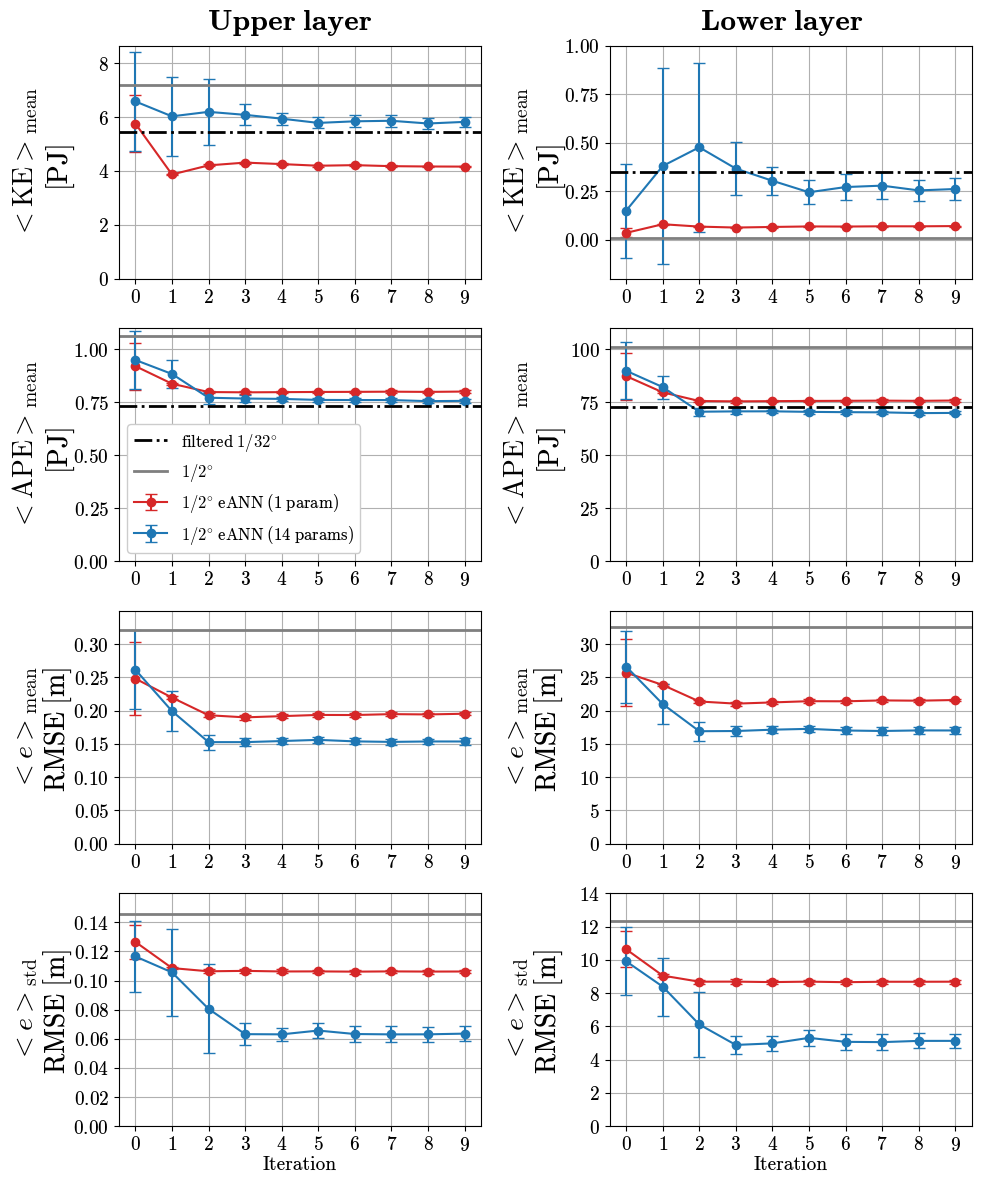

In [86]:
plt.figure(figsize=(10,12))
plot_metrics()
plt.savefig('paper_figures/metrics_transpose.pdf')